# Phase 3c — CDML Seed Identification on LoRA Models

**Thesis:** Code Division Modulation Layers Against Forgetting and Inference in Continual Gait Identification

---

## What this notebook does

Phase 3b established a CDML seed-identification attack on plain `GaitCNN_CDML`:
an attacker who knows all 4 CDML seeds but not which one was used for a specific sample
tries all 4 seeds in turn, reads the max-softmax confidence for each, and guesses the
seed that yields the highest confidence.

**Phase 3c repeats exactly the same attack on the LoRA-enhanced models from Phase 15**
(`GaitCNN_CDML_LoRA` and `WGR-CDML+LoRA`).

In a LoRA model each task has *two* secrets: a **CDML seed** and a **LoRA adapter**.
The focus here remains the same as Phase 3b — **can the attacker guess the CDML seed?**
But LoRA introduces a new variable: does the attacker also possess the per-task adapters?

We test two attacker profiles, both trying to identify the CDML seed by max-softmax:

| Attacker profile | CDML seeds | LoRA adapters |
|---|---|---|
| **Adapter-known** | All 4 (doesn't know which is correct) | All 4 — when probing seed $k$, also loads adapter $k$ |
| **Adapter-unknown** | All 4 (doesn't know which is correct) | None — probes seed $k$ with zeroed LoRA (base weights only) |

Random baseline: **25%** (1 out of 4 seeds chosen at random).

### Research questions
1. With **adapter-known**: does pairing the correct adapter with the correct seed amplify
   the confidence gap, making seed identification *easier* than in Phase 3b?
2. With **adapter-unknown**: does the missing adapter suppress the confidence gap,
   making seed identification *harder* than in Phase 3b?
3. Does WGR replay change identifiability compared to plain CDML+LoRA?


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split, ConcatDataset
from copy import deepcopy
import os
import warnings
warnings.filterwarnings('ignore')

try:
    import pywt
    PYWT_AVAILABLE = True
    print('PyWavelets available — DWT decomposition enabled')
except ImportError:
    PYWT_AVAILABLE = False
    print('PyWavelets not found — using FFT fallback for WGR')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('Using device: MPS (Apple Silicon GPU)')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print('Using device: CUDA (NVIDIA GPU)')
else:
    DEVICE = torch.device('cpu')
    print(f'Using device: CPU')


PyWavelets available — DWT decomposition enabled
Using device: MPS (Apple Silicon GPU)


## 1. Configuration — identical to Phase 3b / 15

In [2]:
TRAIN_DATA_DIR  = '../Data/Dataset_1/train'
TEST_DATA_DIR   = '../Data/Dataset_1/test'

N_CHANNELS      = 6
WINDOW_SIZE     = 128
VAL_SPLIT       = 0.15
RANDOM_SEED     = 27

EPOCHS          = 50
BATCH_SIZE      = 64
LR_INIT         = 1e-3
LR_DECAY        = 0.98

TASK_SPLITS = {
    'Task 1': (1,   30),
    'Task 2': (31,  60),
    'Task 3': (61,  90),
    'Task 4': (91, 118),
}
N_CLASSES_TOTAL = 118
EMBED_DIM       = 128
CDML_SEED_BASE  = 1000
ALL_SEEDS       = [CDML_SEED_BASE + k for k in range(4)]   # [1000, 1001, 1002, 1003]

# LoRA hyperparameters — must match the Phase 15 checkpoint
LORA_RANK  = 8
LORA_ALPHA = 8

# WGR hyperparameters
WGR_WAVELET    = 'db4'
WGR_LEVEL      = 3
WGR_N_SYNTH    = 30
WGR_JITTER_STD = 0.05

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print(f'Seeds: {ALL_SEEDS}')
print(f'LoRA: rank={LORA_RANK}, alpha={LORA_ALPHA}, scaling={LORA_ALPHA/LORA_RANK:.2f}')
print('Configuration set.')


Seeds: [1000, 1001, 1002, 1003]
LoRA: rank=8, alpha=8, scaling=1.00
Configuration set.


## 2. Data loading — identical to Phase 3b / 15

In [3]:
def load_split(data_dir, prefix):
    axes = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']
    signals = [np.loadtxt(f'{data_dir}/Inertial_Signals/{prefix}_{a}.txt') for a in axes]
    X = np.stack(signals, axis=1).astype(np.float32)
    y = np.loadtxt(f'{data_dir}/y_{prefix}.txt', dtype=int)
    return X, y

X_train, y_train = load_split(TRAIN_DATA_DIR, 'train')
X_test,  y_test  = load_split(TEST_DATA_DIR,  'test')
print(f'Train: {X_train.shape}   Test: {X_test.shape}')

ch_mean = X_train.mean(axis=(0, 2), keepdims=True)
ch_std  = X_train.std(axis=(0, 2),  keepdims=True) + 1e-8
X_train_norm = (X_train - ch_mean) / ch_std
X_test_norm  = (X_test  - ch_mean) / ch_std

unique_labels = np.sort(np.unique(np.concatenate([y_train, y_test])))
label_to_idx  = {lbl: idx for idx, lbl in enumerate(unique_labels)}
y_train_idx   = np.array([label_to_idx[l] for l in y_train])
y_test_idx    = np.array([label_to_idx[l] for l in y_test])
print(f'Labels remapped: 0–{y_train_idx.max()}')


def make_task_datasets(X_tr, y_tr_orig, y_tr_idx, X_te, y_te_orig, y_te_idx,
                       task_splits, val_split, seed):
    rng = torch.Generator().manual_seed(seed)
    task_data = {}
    for task_name, (lo, hi) in task_splits.items():
        mask_tr = (y_tr_orig >= lo) & (y_tr_orig <= hi)
        X_t  = torch.tensor(X_tr[mask_tr])
        y_t  = torch.tensor(y_tr_idx[mask_tr], dtype=torch.long)
        full = TensorDataset(X_t, y_t)
        n_val = max(1, int(len(full) * val_split))
        train_ds, val_ds = random_split(full, [len(full) - n_val, n_val], generator=rng)
        mask_te = (y_te_orig >= lo) & (y_te_orig <= hi)
        test_ds = TensorDataset(torch.tensor(X_te[mask_te]),
                                torch.tensor(y_te_idx[mask_te], dtype=torch.long))
        task_data[task_name] = {'train': train_ds, 'val': val_ds, 'test': test_ds}
        print(f'{task_name}: {len(train_ds)} train | {n_val} val | {len(test_ds)} test')
    return task_data

task_data  = make_task_datasets(
    X_train_norm, y_train, y_train_idx,
    X_test_norm,  y_test,  y_test_idx,
    TASK_SPLITS, VAL_SPLIT, RANDOM_SEED)
task_names = list(TASK_SPLITS.keys())
n_tasks    = len(task_names)


Train: (33104, 6, 128)   Test: (3740, 6, 128)
Labels remapped: 0–117
Task 1: 7347 train | 1296 val | 975 test
Task 2: 7241 train | 1277 val | 962 test
Task 3: 6540 train | 1153 val | 871 test
Task 4: 7013 train | 1237 val | 932 test


## 3. Model definitions — reproduced from Phase 15

Self-contained copy so this notebook can run standalone.

### 3.1 Shared backbone (ConvBlock, GaitCNN, CDML)


In [4]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, pool=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=kernel_size // 2),
            nn.ReLU(), nn.MaxPool1d(pool),
        )
    def forward(self, x): return self.block(x)


class GaitCNN(nn.Module):
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128):
        super().__init__()
        self.embed_dim = embed_dim
        self.feature_extractor = nn.Sequential(
            ConvBlock(n_channels, 32), ConvBlock(32, 64),
            ConvBlock(64, 128),        ConvBlock(128, 128), nn.Flatten(),
        )
        flat = self.feature_extractor(torch.zeros(1, n_channels, WINDOW_SIZE)).shape[1]
        self.embedding  = nn.Linear(flat, embed_dim)
        self.classifier = nn.Linear(embed_dim, n_classes)

    def embed(self, x):   return self.embedding(self.feature_extractor(x))
    def forward(self, x): return self.classifier(self.embed(x))


def generate_cdml_sequence(embed_dim, seed):
    rng = np.random.default_rng(seed)
    return torch.tensor(
        np.where(rng.random(embed_dim) >= 0.5, 1.0, -1.0).astype(np.float32))


class CDMLLayer(nn.Module):
    def __init__(self, embed_dim, seed):
        super().__init__()
        self.register_buffer('sequence', generate_cdml_sequence(embed_dim, seed))
    def forward(self, h): return h * self.sequence

print('Backbone + CDML defined.')


Backbone + CDML defined.


### 3.2 LoRALinear — per-task low-rank adapter

One key addition for Phase 3c: `disable_lora()` zeros `lora_B`, making the LoRA
delta exactly zero. This is used to simulate the **adapter-unknown attacker** who
tries CDML seeds against the frozen base weights only.


In [5]:
class LoRALinear(nn.Module):
    """
    Linear layer augmented with Low-Rank Adaptation (Hu et al. 2021).

    Forward:  y = W·x + b  +  (B_k · A_k)·x  × (alpha / rank)

    W is frozen after Task 1.  A_k, B_k are task-specific adapters.
    Setting lora_B = 0 makes the LoRA delta exactly zero (base-only mode).
    """
    def __init__(self, in_features, out_features, rank=LORA_RANK,
                 alpha=LORA_ALPHA, bias=True):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features
        self.rank    = rank
        self.alpha   = alpha
        self.scaling = alpha / rank

        self.weight = nn.Parameter(
            nn.init.kaiming_uniform_(torch.empty(out_features, in_features),
                                     a=np.sqrt(5)))
        if bias:
            bound = 1 / np.sqrt(in_features) if in_features > 0 else 0
            self.bias = nn.Parameter(
                torch.empty(out_features).uniform_(-bound, bound))
        else:
            self.register_parameter('bias', None)

        self.lora_A = nn.Parameter(torch.empty(rank, in_features))
        self.lora_B = nn.Parameter(torch.zeros(out_features, rank))
        nn.init.kaiming_uniform_(self.lora_A, a=np.sqrt(5))

        self._lora_states: dict = {}   # {task_name: (A_cpu, B_cpu)}

    def forward(self, x):
        base = F.linear(x, self.weight, self.bias)
        lora = F.linear(F.linear(x, self.lora_A), self.lora_B) * self.scaling
        return base + lora

    def save_lora(self, task_name):
        self._lora_states[task_name] = (
            self.lora_A.data.cpu().clone(),
            self.lora_B.data.cpu().clone())

    def load_lora(self, task_name):
        A, B = self._lora_states[task_name]
        dev = self.lora_A.device
        self.lora_A.data.copy_(A.to(dev))
        self.lora_B.data.copy_(B.to(dev))

    def disable_lora(self):
        """Zero lora_B so the LoRA delta = 0. Simulates adapter-unknown attacker."""
        nn.init.zeros_(self.lora_B)

    def reset_lora(self):
        nn.init.kaiming_uniform_(self.lora_A, a=np.sqrt(5))
        nn.init.zeros_(self.lora_B)

    def freeze_base(self):
        self.weight.requires_grad_(False)
        if self.bias is not None: self.bias.requires_grad_(False)

    def unfreeze_base(self):
        self.weight.requires_grad_(True)
        if self.bias is not None: self.bias.requires_grad_(True)

    def lora_parameters(self):
        return [self.lora_A, self.lora_B]

print('LoRALinear defined.')


LoRALinear defined.


### 3.3 GaitCNN_LoRA

In [6]:
class GaitCNN_LoRA(nn.Module):
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128,
                 lora_rank=LORA_RANK, lora_alpha=LORA_ALPHA):
        super().__init__()
        self.embed_dim = embed_dim
        self.feature_extractor = nn.Sequential(
            ConvBlock(n_channels, 32), ConvBlock(32, 64),
            ConvBlock(64, 128),        ConvBlock(128, 128), nn.Flatten(),
        )
        flat = self.feature_extractor(
            torch.zeros(1, n_channels, WINDOW_SIZE)).shape[1]
        self.embedding  = LoRALinear(flat, embed_dim, rank=lora_rank, alpha=lora_alpha)
        self.classifier = LoRALinear(embed_dim, n_classes, rank=lora_rank, alpha=lora_alpha)

    def embed(self, x):   return self.embedding(self.feature_extractor(x))
    def forward(self, x): return self.classifier(self.embed(x))

    def save_lora(self, task_name):
        self.embedding.save_lora(task_name)
        self.classifier.save_lora(task_name)

    def load_lora(self, task_name):
        self.embedding.load_lora(task_name)
        self.classifier.load_lora(task_name)

    def disable_lora(self):
        self.embedding.disable_lora()
        self.classifier.disable_lora()

    def reset_lora(self):
        self.embedding.reset_lora()
        self.classifier.reset_lora()

    def freeze_base_weights(self):
        for p in self.feature_extractor.parameters(): p.requires_grad_(False)
        self.embedding.freeze_base()
        self.classifier.freeze_base()

    def lora_parameters(self):
        return self.embedding.lora_parameters() + self.classifier.lora_parameters()

    def trainable_parameter_count(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

print('GaitCNN_LoRA defined.')


GaitCNN_LoRA defined.


### 3.4 GaitCNN_CDML_LoRA — full model

`disable_lora()` is the key method added for Phase 3c. It propagates to both
`LoRALinear` layers and sets `lora_B = 0`, reducing the model to its frozen
base weights + CDML modulation. This is the state in which the adapter-unknown
attacker probes the model.


In [7]:
class GaitCNN_CDML_LoRA(nn.Module):
    """
    GaitCNN_LoRA + CDML modulation.

    Forward:  Input → CNN (frozen T2+)
                    → LoRALinear embedding (base frozen, adapter Aₖ/Bₖ per task)
                    → CDMLLayer (sequence sₖ per task)
                    → LoRALinear classifier (base frozen, adapter Aₖ/Bₖ per task)
                    → logits

    Phase 3c addition: disable_lora() zeros lora_B in both LoRALinear layers,
    making the LoRA contribution identically zero.  Combined with set_task_sequence(),
    this lets us probe the model exactly as an adapter-unknown attacker would.
    """
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128,
                 seed=CDML_SEED_BASE, lora_rank=LORA_RANK, lora_alpha=LORA_ALPHA):
        super().__init__()
        self.embed_dim = embed_dim
        self.backbone  = GaitCNN_LoRA(n_channels, n_classes, embed_dim,
                                       lora_rank, lora_alpha)
        self.cdml      = CDMLLayer(embed_dim, seed)
        self.seeds: dict = {}

    def embed_raw(self, x):
        return self.backbone.embed(x)

    def embed_modulated(self, x):
        return self.cdml(self.backbone.embed(x))

    def forward(self, x):
        h = self.backbone.embed(x)
        m = self.cdml(h)
        return self.backbone.classifier(m)

    # ── CDML sequence management ─────────────────────────────────────────────
    def set_task_sequence(self, task_name, seed):
        self.seeds[task_name] = seed
        self.cdml.sequence = generate_cdml_sequence(
            self.embed_dim, seed).to(next(self.parameters()).device)

    def zero_sequence(self):
        self.cdml.sequence = torch.zeros(
            self.embed_dim, device=next(self.parameters()).device)

    # ── LoRA adapter management ──────────────────────────────────────────────
    def save_lora(self, task_name):   self.backbone.save_lora(task_name)
    def load_lora(self, task_name):   self.backbone.load_lora(task_name)
    def reset_lora(self):             self.backbone.reset_lora()

    def disable_lora(self):
        """
        Zero lora_B in both LoRALinear layers (embedding + classifier).
        After this call the LoRA delta is identically zero: the model runs
        on frozen base weights + CDML modulation only.
        Call load_lora(task_name) to restore a saved adapter.
        """
        self.backbone.disable_lora()

    def freeze_base_weights(self):    self.backbone.freeze_base_weights()
    def lora_parameters(self):        return self.backbone.lora_parameters()
    def trainable_parameter_count(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


_m = GaitCNN_CDML_LoRA(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM)
total_p = sum(p.numel() for p in _m.parameters())
_m.freeze_base_weights()
lora_p  = sum(p.numel() for p in _m.lora_parameters())
print(f'GaitCNN_CDML_LoRA: {total_p:,} total params')
print(f'  LoRA params per task: {lora_p:,}  |  Frozen base: {total_p-lora_p:,}')
del _m


GaitCNN_CDML_LoRA: 238,406 total params
  LoRA params per task: 11,184  |  Frozen base: 227,222


### 3.5 WGR utilities (for WGR-CDML+LoRA) — identical to Phase 15

In [8]:
def _fft_approximate(X_np, low_frac=0.125):
    F   = np.fft.rfft(X_np, axis=-1)
    cut = max(1, int(F.shape[-1] * low_frac))
    F_l = F.copy(); F_l[..., cut:] = 0
    F_h = F.copy(); F_h[..., :cut] = 0
    return (np.fft.irfft(F_l, n=X_np.shape[-1], axis=-1),
            np.fft.irfft(F_h, n=X_np.shape[-1], axis=-1))


class WaveletReplayBuffer:
    """Per-class DWT statistics -> stochastic synthetic gait windows on demand."""
    def __init__(self, wavelet=WGR_WAVELET, level=WGR_LEVEL,
                 n_synth=WGR_N_SYNTH, jitter_std=WGR_JITTER_STD, seed=RANDOM_SEED):
        self.wavelet = wavelet; self.level = level
        self.n_synth = n_synth; self.jitter = jitter_std
        self.rng     = np.random.default_rng(seed)
        self._tasks  = []

    def _to_numpy(self, ds):
        X = torch.stack([ds[i][0] for i in range(len(ds))]).numpy()
        y = torch.stack([ds[i][1] for i in range(len(ds))]).numpy()
        return X, y

    def add_task(self, train_ds, task_name):
        X_np, y_np = self._to_numpy(train_ds)
        N, C, T    = X_np.shape
        classes    = np.unique(y_np)
        if PYWT_AVAILABLE:
            all_c = [[pywt.wavedec(X_np[n, c, :], self.wavelet, level=self.level)
                      for c in range(C)] for n in range(N)]
            class_stats = {}
            for cls in classes:
                mask  = (y_np == cls)
                cA_st = np.array([[all_c[i][c][0] for c in range(C)]
                                   for i in range(N) if mask[i]])
                flat  = cA_st.reshape(cA_st.shape[0], -1)
                class_stats[int(cls)] = {'mu': flat.mean(0), 'sigma': flat.std(0) + 1e-6}
            detail_stats = []
            for lv in range(1, self.level + 1):
                cD = np.array([[all_c[i][c][lv] for c in range(C)] for i in range(N)])
                detail_stats.append({'mu': cD.mean(0), 'sigma': cD.std(0) + 1e-6})
            coeff_lens = [len(a) for a in all_c[0][0]]
        else:
            X_low, X_high = _fft_approximate(X_np)
            class_stats = {
                int(cls): {
                    'mu':    X_low[y_np == cls].reshape(sum(y_np == cls), -1).mean(0),
                    'sigma': X_low[y_np == cls].reshape(sum(y_np == cls), -1).std(0) + 1e-6}
                for cls in classes}
            detail_stats = [{'mu': X_high.mean(0), 'sigma': X_high.std(0) + 1e-6}]
            coeff_lens   = None
        self._tasks.append({'task_name': task_name, 'class_stats': class_stats,
                             'detail_stats': detail_stats, 'coeff_lens': coeff_lens,
                             'n_channels': C, 'window_size': T,
                             'classes': list(classes.astype(int))})
        print(f'  WGR buffer: stored statistics for {task_name} ({len(classes)} classes)')

    def synthesize_task(self, task_idx):
        task = self._tasks[task_idx]
        C, T = task['n_channels'], task['window_size']
        X_list, y_list = [], []
        if PYWT_AVAILABLE:
            for cls, stats in task['class_stats'].items():
                for _ in range(self.n_synth):
                    cA_flat = self.rng.normal(stats['mu'], stats['sigma'])
                    cA      = cA_flat.reshape(C, -1)
                    window  = np.zeros((C, T), dtype=np.float32)
                    for c in range(C):
                        coeffs_c = [cA[c].astype(float)]
                        for lv_s in task['detail_stats']:
                            coeffs_c.append(
                                self.rng.normal(lv_s['mu'][c], lv_s['sigma'][c]).astype(float))
                        recon = pywt.waverec(coeffs_c, self.wavelet)
                        window[c] = (recon[:T] if len(recon) >= T
                                     else np.pad(recon.astype(np.float32), (0, T - len(recon))))
                    window += self.rng.normal(0, self.jitter, window.shape).astype(np.float32)
                    X_list.append(window); y_list.append(cls)
        else:
            for cls, stats in task['class_stats'].items():
                det = task['detail_stats'][0]
                for _ in range(self.n_synth):
                    xl = self.rng.normal(stats['mu'], stats['sigma']).reshape(C, T // 4)
                    xl = np.repeat(xl, 4, axis=-1)[:, :T]
                    xh = self.rng.normal(det['mu'], det['sigma']).reshape(C, -1)[:, :T]
                    if xh.shape[-1] < T:
                        xh = np.pad(xh, ((0, 0), (0, T - xh.shape[-1])))
                    window = (xl + xh).astype(np.float32)
                    window += self.rng.normal(0, self.jitter, window.shape).astype(np.float32)
                    X_list.append(window); y_list.append(cls)
        return TensorDataset(torch.tensor(np.stack(X_list)),
                             torch.tensor(y_list, dtype=torch.long))

    def get_replay_dataset(self):
        if not self._tasks: return None
        return ConcatDataset([self.synthesize_task(i) for i in range(len(self._tasks))])

print('WGR utilities defined.')


WGR utilities defined.


## 4. Training utilities — identical to Phase 15

In [9]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    c, t = 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        c += (model(X_b).argmax(1) == y_b).sum().item()
        t += len(y_b)
    return c / t if t > 0 else 0.0


def _run_epoch(model, loader, optimizer, criterion, device):
    model.train()
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        criterion(model(X_b), y_b).backward()
        optimizer.step()


def _eval_all_tasks(model, task_data, task_names, step_idx, acc_mat, device):
    for ei, et in enumerate(task_names[:step_idx + 1]):
        model.set_task_sequence(et, model.seeds[et])
        model.load_lora(et)
        tl = DataLoader(task_data[et]['test'], batch_size=256)
        acc_mat[step_idx, ei] = evaluate(model, tl, device)
    # Restore current task
    cur = task_names[step_idx]
    model.set_task_sequence(cur, model.seeds.get(cur, CDML_SEED_BASE + step_idx))
    model.load_lora(cur)

print('Training utilities defined.')


Training utilities defined.


In [10]:
def train_cdml_lora(task_data, task_names, device, epochs, lr_init, lr_decay,
                    batch_size, label='CDML+LoRA', verbose_every=25):
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN_CDML_LoRA(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)

    for step_idx, task_name in enumerate(task_names):
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)
        model.reset_lora()

        print(f'[{label}] Step {step_idx+1}: {task_name}  seed={seed_k}')

        if step_idx == 0:
            optimizer = optim.Adam(model.parameters(), lr=lr_init)
        else:
            model.freeze_base_weights()
            optimizer = optim.Adam(model.lora_parameters(), lr=lr_init)

        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        loader    = DataLoader(task_data[task_name]['train'],
                               batch_size=batch_size, shuffle=True)

        for epoch in range(1, epochs + 1):
            model.set_task_sequence(task_name, seed_k)
            _run_epoch(model, loader, optimizer, criterion, device)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl  = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                acc = evaluate(model, vl, device)
                print(f'  Epoch {epoch:>3}/{epochs}  val={acc:.3f}')

        model.save_lora(task_name)
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix, device)
        print('  ->', '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%'
                                  for j in range(step_idx + 1)]))
    return model, acc_matrix

print('train_cdml_lora defined.')


train_cdml_lora defined.


In [11]:
def train_wgr_cdml_lora(task_data, task_names, device, epochs, lr_init, lr_decay,
                         batch_size, label='WGR-CDML+LoRA', verbose_every=25):
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN_CDML_LoRA(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    wgr_buf    = WaveletReplayBuffer()

    for step_idx, task_name in enumerate(task_names):
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)
        model.reset_lora()

        print(f'[{label}] Step {step_idx+1}: {task_name}  seed={seed_k}')

        datasets = [task_data[task_name]['train']]
        if step_idx > 0:
            synth = wgr_buf.get_replay_dataset()
            if synth is not None:
                datasets.append(synth)
                print(f'  + {len(synth)} synthetic replay samples')

        if step_idx == 0:
            optimizer = optim.Adam(model.parameters(), lr=lr_init)
        else:
            model.freeze_base_weights()
            optimizer = optim.Adam(model.lora_parameters(), lr=lr_init)

        loader    = DataLoader(ConcatDataset(datasets), batch_size=batch_size, shuffle=True)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)

        for epoch in range(1, epochs + 1):
            model.set_task_sequence(task_name, seed_k)
            _run_epoch(model, loader, optimizer, criterion, device)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl  = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                acc = evaluate(model, vl, device)
                print(f'  Epoch {epoch:>3}/{epochs}  val={acc:.3f}')

        model.save_lora(task_name)
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix, device)
        print('  ->', '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%'
                                  for j in range(step_idx + 1)]))
        wgr_buf.add_task(task_data[task_name]['train'], task_name)
    return model, acc_matrix

print('train_wgr_cdml_lora defined.')


train_wgr_cdml_lora defined.


## 5. Load Phase 15 checkpoints (or retrain if not found)




In [12]:
CHECKPOINT15_PATH = 'checkpoint_phase15.pt'

_kwargs = dict(n_channels=N_CHANNELS, n_classes=N_CLASSES_TOTAL,
               embed_dim=EMBED_DIM, lora_rank=LORA_RANK, lora_alpha=LORA_ALPHA)


def restore_lora_model(ckpt, prefix, device, **kwargs):
    model = GaitCNN_CDML_LoRA(**kwargs).to(device)
    model.load_state_dict(ckpt[f'{prefix}_state_dict'])
    # _lora_states are plain Python dicts, not nn buffers — restore separately
    model.backbone.embedding._lora_states  = ckpt[f'{prefix}_emb_lora']
    model.backbone.classifier._lora_states = ckpt[f'{prefix}_cls_lora']
    model.seeds = ckpt[f'{prefix}_seeds']
    return model


def save_phase15_checkpoint(m_cl, m_wl, path):
    torch.save({
        'cdml_lora_state_dict': m_cl.state_dict(),
        'cdml_lora_emb_lora':   m_cl.backbone.embedding._lora_states,
        'cdml_lora_cls_lora':   m_cl.backbone.classifier._lora_states,
        'cdml_lora_seeds':      m_cl.seeds,
        'wgr_lora_state_dict':  m_wl.state_dict(),
        'wgr_lora_emb_lora':    m_wl.backbone.embedding._lora_states,
        'wgr_lora_cls_lora':    m_wl.backbone.classifier._lora_states,
        'wgr_lora_seeds':       m_wl.seeds,
    }, path)
    print(f'Checkpoint saved to {path}')


if os.path.exists(CHECKPOINT15_PATH):
    print(f'Loading Phase 15 checkpoint from {CHECKPOINT15_PATH!r} ...')
    ckpt = torch.load(CHECKPOINT15_PATH, map_location=DEVICE)
    model_cdml_lora = restore_lora_model(ckpt, 'cdml_lora', DEVICE, **_kwargs)
    model_wgr_lora  = restore_lora_model(ckpt, 'wgr_lora',  DEVICE, **_kwargs)
    print('Checkpoint loaded.')
    print(f'  CDML+LoRA  seeds:    {model_cdml_lora.seeds}')
    print(f'  WGR+LoRA   seeds:    {model_wgr_lora.seeds}')
    print(f'  CDML+LoRA  adapters: {list(model_cdml_lora.backbone.embedding._lora_states)}')
    print(f'  WGR+LoRA   adapters: {list(model_wgr_lora.backbone.embedding._lora_states)}')
else:
    print(f'Checkpoint not found — training from scratch (EPOCHS={EPOCHS})')
    print('Tip: run Phase 15 and save a checkpoint there to skip this step.\n')
    model_cdml_lora, _ = train_cdml_lora(
        task_data, task_names, DEVICE, EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE)
    print()
    model_wgr_lora, _ = train_wgr_cdml_lora(
        task_data, task_names, DEVICE, EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE)
    save_phase15_checkpoint(model_cdml_lora, model_wgr_lora, CHECKPOINT15_PATH)


Checkpoint not found — training from scratch (EPOCHS=50)
Tip: run Phase 15 and save a checkpoint there to skip this step.

[CDML+LoRA] Step 1: Task 1  seed=1000
  Epoch   1/50  val=0.944
  Epoch  25/50  val=0.992
  Epoch  50/50  val=0.991
  -> T1:90.3%
[CDML+LoRA] Step 2: Task 2  seed=1001
  Epoch   1/50  val=0.608
  Epoch  25/50  val=0.958
  Epoch  50/50  val=0.971
  -> T1:90.3%  T2:91.3%
[CDML+LoRA] Step 3: Task 3  seed=1002
  Epoch   1/50  val=0.425
  Epoch  25/50  val=0.956
  Epoch  50/50  val=0.964
  -> T1:90.3%  T2:91.3%  T3:88.9%
[CDML+LoRA] Step 4: Task 4  seed=1003
  Epoch   1/50  val=0.665
  Epoch  25/50  val=0.972
  Epoch  50/50  val=0.978
  -> T1:90.3%  T2:91.3%  T3:88.9%  T4:95.7%

[WGR-CDML+LoRA] Step 1: Task 1  seed=1000
  Epoch   1/50  val=0.944
  Epoch  25/50  val=0.992
  Epoch  50/50  val=0.991
  -> T1:90.3%
  WGR buffer: stored statistics for Task 1 (30 classes)
[WGR-CDML+LoRA] Step 2: Task 2  seed=1001
  + 900 synthetic replay samples
  Epoch   1/50  val=0.617
  Epo

## 6. CDML seed identification experiments

The experiment mirrors Phase 3b exactly:

> For each test sample from task $k$ (true secret = seed $k$), the attacker tries all 4
> candidate seeds and picks the one that produces the **highest max-softmax confidence**.
> Success = the guessed seed index matches the true task index $k$.

The only new variable is what the attacker does about **LoRA adapters** during each probe:

| `probe_mode` | What the attacker does when probing candidate seed $j$ |
|---|---|
| `adapter_known` | Also loads adapter $j$ from the known set — correct seed + correct adapter → highest confidence expected |
| `adapter_unknown` | Calls `disable_lora()` — zeroes `lora_B`, so the LoRA delta is zero for all probes |

In both modes the **seed identification metric is identical** to Phase 3b:
did the max-confidence seed index match the true task index?


In [13]:
@torch.no_grad()
def seed_identification_experiment_lora(model, task_data, task_names, all_seeds,
                                         device, probe_mode='adapter_known',
                                         batch_size=64):
    """
    CDML seed identification by max-softmax confidence.

    Parameters
    ----------
    probe_mode : 'adapter_known' | 'adapter_unknown'
        'adapter_known'   -- when probing candidate seed j, also loads adapter j.
                            Attacker has ALL seeds AND ALL adapters but does not
                            know which (seed, adapter) pair belongs to this sample.
        'adapter_unknown' -- calls disable_lora() before every probe so lora_B = 0.
                            Attacker has the seeds but does NOT have the adapters;
                            probes against the frozen base weights + CDML only.

    Returns
    -------
    dict keyed by task_name, each containing:
        accuracy           float  -- fraction of samples correctly identified
        rank_counts        array  -- how often the correct seed ranked 0,1,2,3
        confidences        array  -- (n_samples, n_seeds) max-softmax matrix
        predicted_seed_idx array  -- argmax seed index per sample
        correct            array  -- bool mask of correct identifications
        true_seed          int
        true_seed_idx      int
    """
    model.eval()
    n_seeds  = len(all_seeds)
    per_task = {}

    for true_idx, task_name in enumerate(task_names):
        true_seed   = all_seeds[true_idx]
        test_loader = DataLoader(task_data[task_name]['test'],
                                 batch_size=batch_size, shuffle=False)
        all_conf, all_labels = [], []

        for X_b, y_b in test_loader:
            X_b = X_b.to(device)
            batch_conf = []

            for cand_idx, cand_seed in enumerate(all_seeds):
                # ── Step 1: set the CDML sequence ────────────────────────────
                model.set_task_sequence('_probe', cand_seed)

                # ── Step 2: configure LoRA based on attacker knowledge ───────
                if probe_mode == 'adapter_known':
                    # Attacker loads the adapter matching this seed guess
                    model.load_lora(task_names[cand_idx])
                else:   # 'adapter_unknown'
                    # Attacker has no adapters: zero lora_B → LoRA delta = 0
                    model.disable_lora()

                logits = model(X_b)
                probs  = torch.softmax(logits, dim=1)
                max_p  = probs.max(dim=1).values.cpu().numpy()
                batch_conf.append(max_p)

            all_conf.append(np.stack(batch_conf, axis=1))   # (B, n_seeds)
            all_labels.append(y_b.numpy())

        conf    = np.concatenate(all_conf,   axis=0)   # (n_samples, n_seeds)
        labels  = np.concatenate(all_labels, axis=0)

        pred_idx    = conf.argmax(axis=1)
        correct     = (pred_idx == true_idx)
        acc         = correct.mean()
        # Rank of the correct seed (0 = attacker succeeded, 3 = most wrong)
        ranks       = (conf > conf[:, true_idx:true_idx + 1]).sum(axis=1)
        rank_counts = np.bincount(ranks, minlength=n_seeds)

        per_task[task_name] = {
            'true_seed'          : true_seed,
            'true_seed_idx'      : true_idx,
            'confidences'        : conf,
            'labels'             : labels,
            'predicted_seed_idx' : pred_idx,
            'correct'            : correct,
            'accuracy'           : acc,
            'rank_counts'        : rank_counts,
        }
        print(f'  {task_name} (true seed={true_seed}): '
              f'ID acc={acc * 100:.1f}%  '
              f'| rank-0={rank_counts[0] / len(correct) * 100:.1f}%  '
              f'(random baseline={100 / n_seeds:.1f}%)')

    return per_task

print('seed_identification_experiment_lora defined.')


seed_identification_experiment_lora defined.


In [14]:
n_seeds  = len(ALL_SEEDS)
baseline = 1.0 / n_seeds

# ── CDML+LoRA ────────────────────────────────────────────────────────────────
print('=' * 65)
print('CDML+LoRA  |  Adapter-known  (attacker has seeds + adapters)')
print('=' * 65)
results_cdml_ak = seed_identification_experiment_lora(
    model_cdml_lora, task_data, task_names, ALL_SEEDS, DEVICE,
    probe_mode='adapter_known')

print()
print('=' * 65)
print('CDML+LoRA  |  Adapter-unknown  (attacker has seeds only)')
print('=' * 65)
results_cdml_au = seed_identification_experiment_lora(
    model_cdml_lora, task_data, task_names, ALL_SEEDS, DEVICE,
    probe_mode='adapter_unknown')

# ── WGR-CDML+LoRA ────────────────────────────────────────────────────────────
print()
print('=' * 65)
print('WGR-CDML+LoRA  |  Adapter-known')
print('=' * 65)
results_wgr_ak = seed_identification_experiment_lora(
    model_wgr_lora, task_data, task_names, ALL_SEEDS, DEVICE,
    probe_mode='adapter_known')

print()
print('=' * 65)
print('WGR-CDML+LoRA  |  Adapter-unknown')
print('=' * 65)
results_wgr_au = seed_identification_experiment_lora(
    model_wgr_lora, task_data, task_names, ALL_SEEDS, DEVICE,
    probe_mode='adapter_unknown')


CDML+LoRA  |  Adapter-known  (attacker has seeds + adapters)
  Task 1 (true seed=1000): ID acc=95.7%  | rank-0=95.7%  (random baseline=25.0%)
  Task 2 (true seed=1001): ID acc=48.4%  | rank-0=48.5%  (random baseline=25.0%)
  Task 3 (true seed=1002): ID acc=57.2%  | rank-0=57.3%  (random baseline=25.0%)
  Task 4 (true seed=1003): ID acc=58.5%  | rank-0=60.4%  (random baseline=25.0%)

CDML+LoRA  |  Adapter-unknown  (attacker has seeds only)
  Task 1 (true seed=1000): ID acc=97.8%  | rank-0=97.8%  (random baseline=25.0%)
  Task 2 (true seed=1001): ID acc=24.2%  | rank-0=24.2%  (random baseline=25.0%)
  Task 3 (true seed=1002): ID acc=24.2%  | rank-0=24.2%  (random baseline=25.0%)
  Task 4 (true seed=1003): ID acc=15.1%  | rank-0=15.1%  (random baseline=25.0%)

WGR-CDML+LoRA  |  Adapter-known
  Task 1 (true seed=1000): ID acc=97.1%  | rank-0=97.1%  (random baseline=25.0%)
  Task 2 (true seed=1001): ID acc=55.9%  | rank-0=56.0%  (random baseline=25.0%)
  Task 3 (true seed=1002): ID acc=52.7

## 7. Summary statistics

In [15]:
ALL_RESULTS = {
    'CDML+LoRA     | Adapter-known':   results_cdml_ak,
    'CDML+LoRA     | Adapter-unknown': results_cdml_au,
    'WGR-CDML+LoRA | Adapter-known':   results_wgr_ak,
    'WGR-CDML+LoRA | Adapter-unknown': results_wgr_au,
}

sep = '=' * 76
print(sep)
print('CDML SEED IDENTIFICATION ACCURACY   (random baseline = 25.0%)')
print(sep)
print(f'  {"Scenario":<38} | ' +
      ' | '.join([f'{t:>8}' for t in task_names]) + ' |   Avg')
print('  ' + '-' * 72)
for scenario, res in ALL_RESULTS.items():
    accs = [res[t]['accuracy'] * 100 for t in task_names]
    mean = np.mean(accs)
    row  = ' | '.join([f'{a:>7.1f}%' for a in accs])
    print(f'  {scenario:<38} | {row} | {mean:>5.1f}%')
print(f'  {"Random baseline":<38} |' + '   25.0% |' * len(task_names) + '   25.0%')

print()
print('RANK-0 RATE  (% of samples where correct seed had highest confidence)')
print(sep)
print(f'  {"Scenario":<38} | ' +
      ' | '.join([f'{t:>8}' for t in task_names]))
print('  ' + '-' * 68)
for scenario, res in ALL_RESULTS.items():
    r0s = [res[t]['rank_counts'][0] / len(res[t]['correct']) * 100
           for t in task_names]
    row = ' | '.join([f'{r:>7.1f}%' for r in r0s])
    print(f'  {scenario:<38} | {row}')


CDML SEED IDENTIFICATION ACCURACY   (random baseline = 25.0%)
  Scenario                               |   Task 1 |   Task 2 |   Task 3 |   Task 4 |   Avg
  ------------------------------------------------------------------------
  CDML+LoRA     | Adapter-known          |    95.7% |    48.4% |    57.2% |    58.5% |  64.9%
  CDML+LoRA     | Adapter-unknown        |    97.8% |    24.2% |    24.2% |    15.1% |  40.4%
  WGR-CDML+LoRA | Adapter-known          |    97.1% |    55.9% |    52.7% |    43.9% |  62.4%
  WGR-CDML+LoRA | Adapter-unknown        |    97.8% |    24.2% |    24.2% |    15.1% |  40.4%
  Random baseline                        |   25.0% |   25.0% |   25.0% |   25.0% |   25.0%

RANK-0 RATE  (% of samples where correct seed had highest confidence)
  Scenario                               |   Task 1 |   Task 2 |   Task 3 |   Task 4
  --------------------------------------------------------------------
  CDML+LoRA     | Adapter-known          |    95.7% |    48.5% |    57.3% | 

## 8. Visualizations

### 8a. Seed identification accuracy — adapter-known vs adapter-unknown

Solid bars = adapter-known attacker (has both CDML seeds and LoRA adapters).
Hatched bars = adapter-unknown attacker (has CDML seeds, probes with zeroed LoRA).


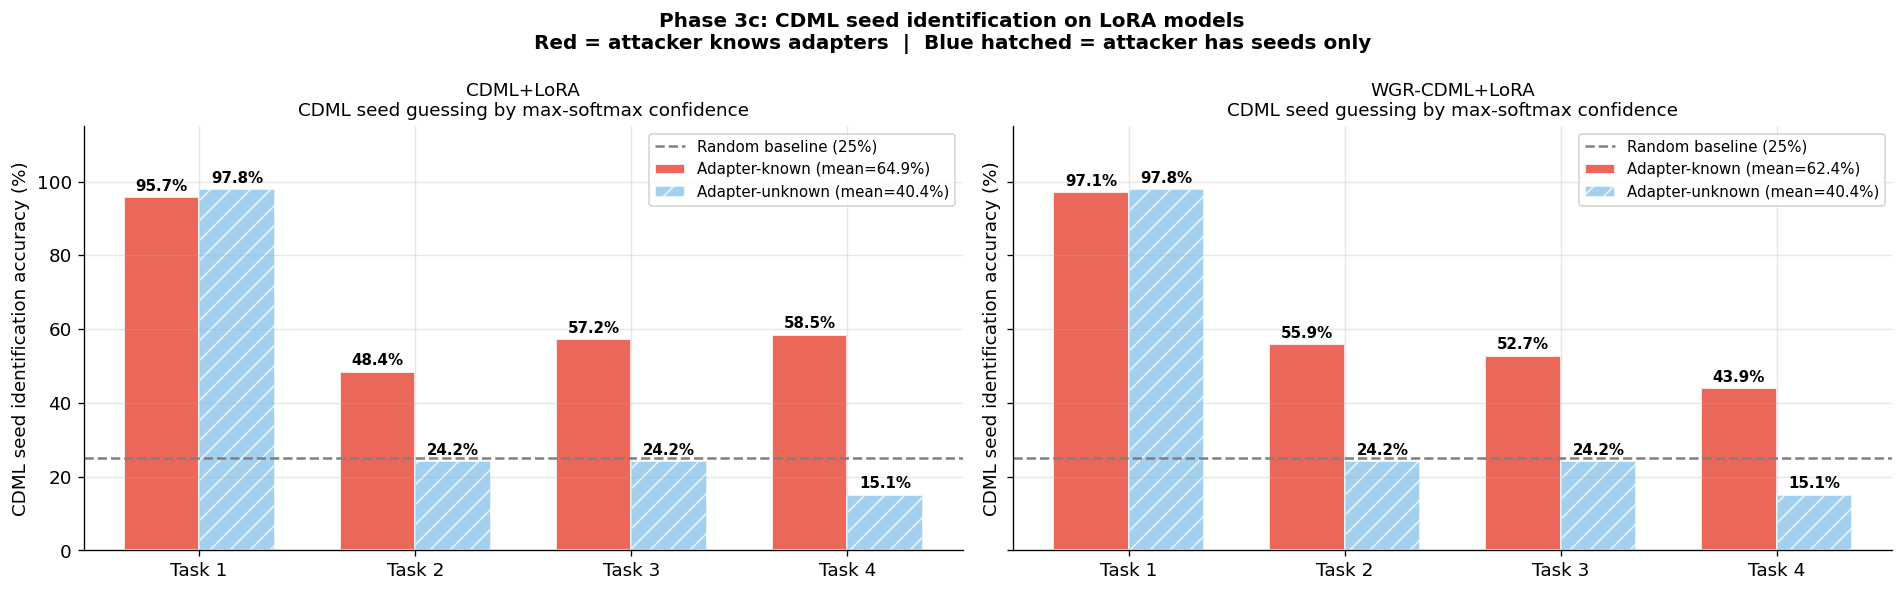

Saved: fig_3c_seed_id_accuracy.png


In [16]:
import os; os.makedirs('../Plots', exist_ok=True)

task_colors = ['#4C9BE8', '#6DB56D', '#E8864C', '#B06DB5']

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, (model_label, res_ak, res_au) in zip(axes, [
    ('CDML+LoRA',     results_cdml_ak, results_cdml_au),
    ('WGR-CDML+LoRA', results_wgr_ak,  results_wgr_au),
]):
    x     = np.arange(len(task_names))
    width = 0.35

    acc_ak = [res_ak[t]['accuracy'] * 100 for t in task_names]
    acc_au = [res_au[t]['accuracy'] * 100 for t in task_names]

    b1 = ax.bar(x - width / 2, acc_ak, width, alpha=0.85, color='#E74C3C',
                edgecolor='white', linewidth=1.2,
                label=f'Adapter-known (mean={np.mean(acc_ak):.1f}%)')
    b2 = ax.bar(x + width / 2, acc_au, width, alpha=0.75, color='#85C1E9',
                edgecolor='white', linewidth=1.2, hatch='//',
                label=f'Adapter-unknown (mean={np.mean(acc_au):.1f}%)')

    ax.axhline(baseline * 100, color='gray', linestyle='--', lw=1.5,
               label=f'Random baseline ({baseline * 100:.0f}%)')

    for bar, val in list(zip(b1, acc_ak)) + list(zip(b2, acc_au)):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xticks(x); ax.set_xticklabels(task_names)
    ax.set_ylim(0, 115)
    ax.set_ylabel('CDML seed identification accuracy (%)')
    ax.set_title(f'{model_label}\nCDML seed guessing by max-softmax confidence', fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('Phase 3c: CDML seed identification on LoRA models\n'
             'Red = attacker knows adapters  |  Blue hatched = attacker has seeds only',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../Plots/fig_3c_seed_id_accuracy.png', bbox_inches='tight')
plt.show()
print('Saved: fig_3c_seed_id_accuracy.png')


### 8b. Confusion matrices — true seed vs predicted seed

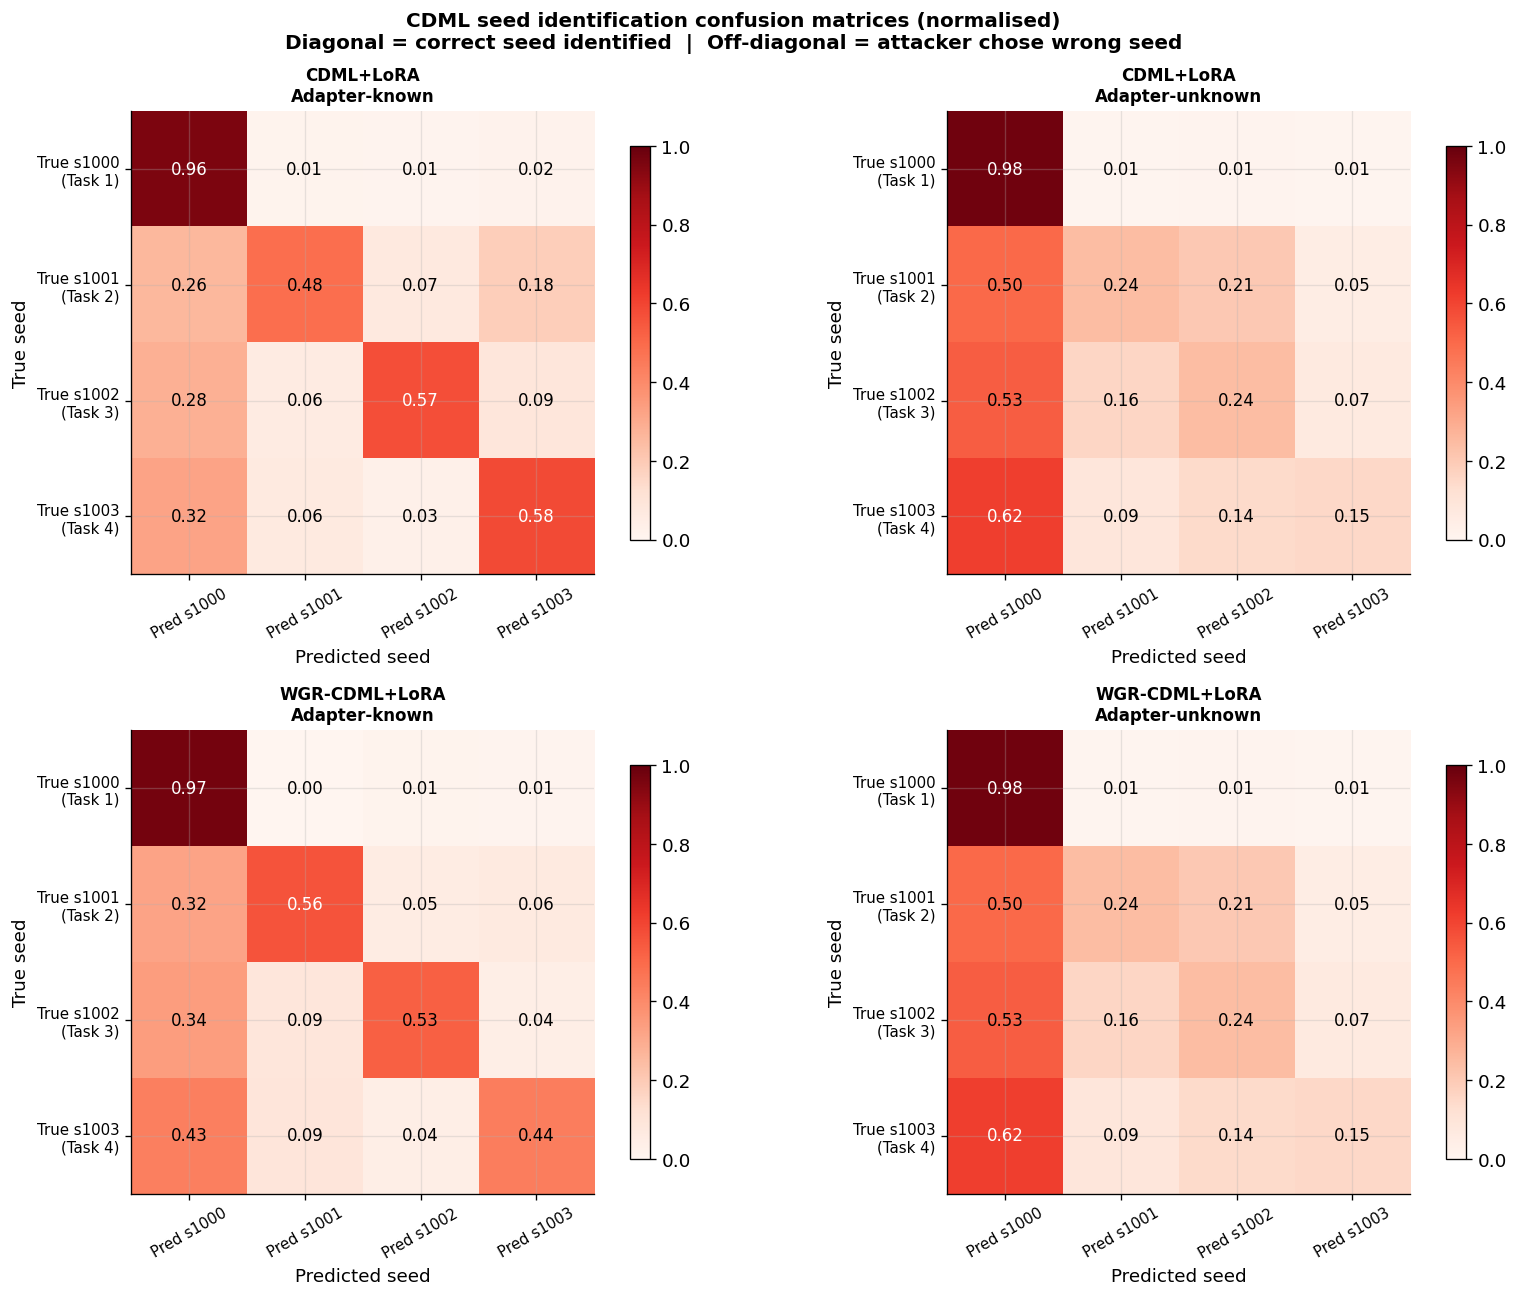

Saved: fig_3c_confusion_matrices.png


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for row_idx, (model_label, res_ak, res_au) in enumerate([
    ('CDML+LoRA',     results_cdml_ak, results_cdml_au),
    ('WGR-CDML+LoRA', results_wgr_ak,  results_wgr_au),
]):
    for col_idx, (probe_label, results) in enumerate([
        ('Adapter-known',   res_ak),
        ('Adapter-unknown', res_au),
    ]):
        ax   = axes[row_idx, col_idx]
        cmat = np.zeros((n_seeds, n_seeds), dtype=int)
        for task_idx, (task_name, r) in enumerate(results.items()):
            for pred in r['predicted_seed_idx']:
                cmat[task_idx, pred] += 1
        cmat_norm = cmat / (cmat.sum(axis=1, keepdims=True) + 1e-9)

        im = ax.imshow(cmat_norm, cmap='Reds' if 'known' in probe_label else 'Blues',
                       vmin=0, vmax=1)
        plt.colorbar(im, ax=ax, shrink=0.85)
        ax.set_xticks(range(n_seeds))
        ax.set_yticks(range(n_seeds))
        ax.set_xticklabels([f'Pred s{CDML_SEED_BASE+i}' for i in range(n_seeds)],
                            rotation=30, fontsize=9)
        ax.set_yticklabels([f'True s{CDML_SEED_BASE+i}\n(Task {i+1})'
                             for i in range(n_seeds)], fontsize=9)
        ax.set_xlabel('Predicted seed'); ax.set_ylabel('True seed')
        ax.set_title(f'{model_label}\n{probe_label}', fontsize=10, fontweight='bold')
        for r_i in range(n_seeds):
            for c_i in range(n_seeds):
                v = cmat_norm[r_i, c_i]
                ax.text(c_i, r_i, f'{v:.2f}', ha='center', va='center',
                        fontsize=10, color='white' if v > 0.55 else 'black')

plt.suptitle('CDML seed identification confusion matrices (normalised)\n'
             'Diagonal = correct seed identified  |  '
             'Off-diagonal = attacker chose wrong seed',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../Plots/fig_3c_confusion_matrices.png', bbox_inches='tight')
plt.show()
print('Saved: fig_3c_confusion_matrices.png')


### 8c. Rank distribution of the correct CDML seed

Rank 0 = the correct seed had the **highest** confidence (attacker succeeded).
Rank 3 = the correct seed had the **lowest** confidence (attacker was maximally wrong).


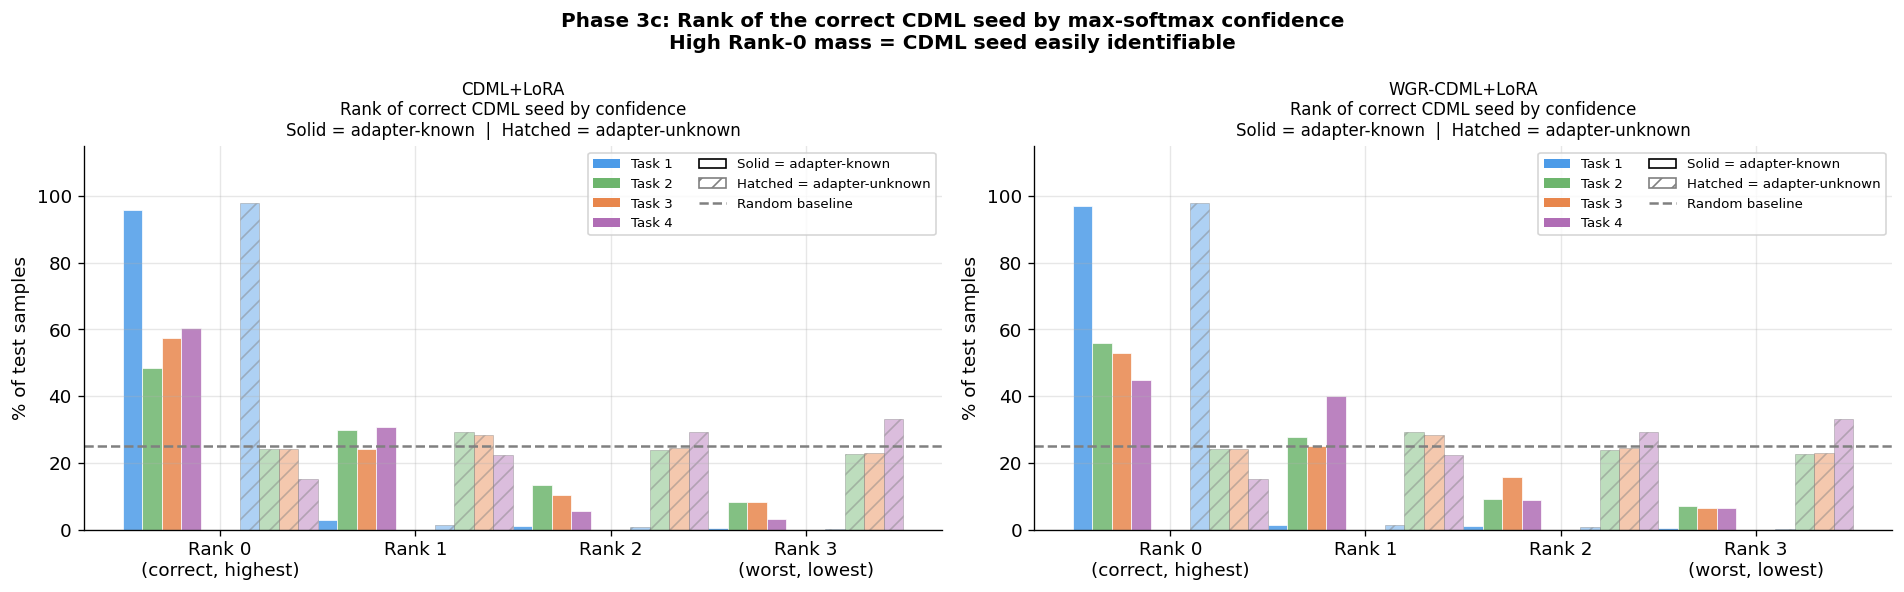

Saved: fig_3c_rank_distributions.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (model_label, res_ak, res_au) in zip(axes, [
    ('CDML+LoRA',     results_cdml_ak, results_cdml_au),
    ('WGR-CDML+LoRA', results_wgr_ak,  results_wgr_au),
]):
    x     = np.arange(n_seeds)
    width = 0.10
    n_t   = len(task_names)
    half  = (n_t - 1) / 2.0

    for t_idx, (task_name, color) in enumerate(zip(task_names, task_colors)):
        off = (t_idx - half) * width

        # Adapter-known — solid
        n_j    = len(res_ak[task_name]['correct'])
        fracs  = res_ak[task_name]['rank_counts'] / n_j * 100
        ax.bar(x + off - 0.3, fracs, width=width, color=color, alpha=0.85,
               edgecolor='white', linewidth=0.5, label=f'AK {task_name}')

        # Adapter-unknown — hatched, shifted right
        n_u    = len(res_au[task_name]['correct'])
        fracs2 = res_au[task_name]['rank_counts'] / n_u * 100
        ax.bar(x + off + 0.3, fracs2, width=width, color=color, alpha=0.45,
               hatch='//', edgecolor='gray', linewidth=0.5, label=f'AU {task_name}')

    ax.axhline(baseline * 100, color='gray', linestyle='--', lw=1.5,
               label=f'Random ({baseline * 100:.0f}%)')
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(['Rank 0\n(correct, highest)',
                        'Rank 1', 'Rank 2',
                        'Rank 3\n(worst, lowest)'])
    ax.set_ylabel('% of test samples')
    ax.set_ylim(0, 115)
    ax.set_title(f'{model_label}\nRank of correct CDML seed by confidence\n'
                 f'Solid = adapter-known  |  Hatched = adapter-unknown', fontsize=10)

    from matplotlib.patches import Patch
    legend_els = [Patch(facecolor=task_colors[i], label=task_names[i])
                  for i in range(n_t)]
    legend_els += [
        Patch(facecolor='white', edgecolor='black', label='Solid = adapter-known'),
        Patch(facecolor='white', edgecolor='gray', hatch='//',
              label='Hatched = adapter-unknown'),
        plt.Line2D([0], [0], color='gray', ls='--', lw=1.5, label='Random baseline'),
    ]
    ax.legend(handles=legend_els, fontsize=8, loc='upper right', ncol=2)

plt.suptitle('Phase 3c: Rank of the correct CDML seed by max-softmax confidence\n'
             'High Rank-0 mass = CDML seed easily identifiable',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../Plots/fig_3c_rank_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: fig_3c_rank_distributions.png')


## 9. Impact on classification: oracle vs identified-seed accuracy

Once the attacker has guessed the CDML seed (correctly or not), how much does it help
them classify subjects?  We compare three conditions:

| Condition | Seed used | LoRA adapter used |
|---|---|---|
| **Oracle** | Correct seed | Correct adapter (upper bound) |
| **Adapter-known, seed identified** | Identified seed | Adapter matching identified seed |
| **Adapter-unknown, seed identified** | Identified seed | None (zeroed LoRA) |

Gaps from oracle quantify the *practical* privacy protection remaining even after
a partial identification attempt.


In [19]:
@torch.no_grad()
def evaluate_with_identified_seed_lora(model, task_data, task_names, all_seeds,
                                         device, results_ak, results_au,
                                         batch_size=64):
    """
    For each task, compute classification accuracy in three conditions:
      oracle      -- correct seed + correct adapter (upper bound)
      ak_id       -- identified seed + matching adapter (adapter-known ID)
      au_id       -- identified seed + zeroed LoRA    (adapter-unknown ID)

    Note: the 'au_id' condition probes the same way the adapter-unknown attacker
    does, i.e. with disabled LoRA adapters.  It is therefore a lower-quality
    classification setting than 'ak_id'.
    """
    model.eval()
    oracle_accs = []
    ak_id_accs  = []
    au_id_accs  = []

    for true_idx, task_name in enumerate(task_names):
        true_seed = all_seeds[true_idx]

        test_loader = DataLoader(task_data[task_name]['test'],
                                 batch_size=batch_size, shuffle=False)
        all_X, all_y = [], []
        for X_b, y_b in test_loader:
            all_X.append(X_b); all_y.append(y_b)
        all_X = torch.cat(all_X, dim=0)
        all_y = torch.cat(all_y, dim=0)

        # ── Oracle ───────────────────────────────────────────────────────────
        model.set_task_sequence('_eval', true_seed)
        model.load_lora(task_name)
        logits = model(all_X.to(device))
        oracle_acc = (logits.argmax(1) == all_y.to(device)).float().mean().item()
        oracle_accs.append(oracle_acc)

        # ── Adapter-known identification ──────────────────────────────────────
        pred_ak = results_ak[task_name]['predicted_seed_idx']
        c, t    = 0, 0
        for seed_idx, seed in enumerate(all_seeds):
            mask = (pred_ak == seed_idx)
            if mask.sum() == 0: continue
            model.set_task_sequence('_eval', seed)
            model.load_lora(task_names[seed_idx])   # adapter matches seed guess
            logits = model(all_X[mask].to(device))
            c += (logits.argmax(1) == all_y[mask].to(device)).sum().item()
            t += mask.sum().item()
        ak_id_accs.append(c / t if t > 0 else 0.0)

        # ── Adapter-unknown identification ────────────────────────────────────
        pred_au = results_au[task_name]['predicted_seed_idx']
        c, t    = 0, 0
        for seed_idx, seed in enumerate(all_seeds):
            mask = (pred_au == seed_idx)
            if mask.sum() == 0: continue
            model.set_task_sequence('_eval', seed)
            model.disable_lora()                    # no adapter available
            logits = model(all_X[mask].to(device))
            c += (logits.argmax(1) == all_y[mask].to(device)).sum().item()
            t += mask.sum().item()
        au_id_accs.append(c / t if t > 0 else 0.0)

        print(f'  {task_name}: '
              f'oracle={oracle_acc*100:.1f}%  '
              f'AK-id={ak_id_accs[-1]*100:.1f}%  '
              f'AU-id={au_id_accs[-1]*100:.1f}%  '
              f'(seed-ID acc: AK={results_ak[task_name]["accuracy"]*100:.1f}%, '
              f'AU={results_au[task_name]["accuracy"]*100:.1f}%)')

    return oracle_accs, ak_id_accs, au_id_accs

print('evaluate_with_identified_seed_lora defined.')


evaluate_with_identified_seed_lora defined.


In [20]:
print('CDML+LoRA:')
oracle_cl, ak_cl, au_cl = evaluate_with_identified_seed_lora(
    model_cdml_lora, task_data, task_names, ALL_SEEDS, DEVICE,
    results_cdml_ak, results_cdml_au)

print()
print('WGR-CDML+LoRA:')
oracle_wl, ak_wl, au_wl = evaluate_with_identified_seed_lora(
    model_wgr_lora, task_data, task_names, ALL_SEEDS, DEVICE,
    results_wgr_ak, results_wgr_au)


CDML+LoRA:
  Task 1: oracle=90.3%  AK-id=87.7%  AU-id=88.7%  (seed-ID acc: AK=95.7%, AU=97.8%)
  Task 2: oracle=91.3%  AK-id=47.6%  AU-id=0.0%  (seed-ID acc: AK=48.4%, AU=24.2%)
  Task 3: oracle=88.9%  AK-id=56.4%  AU-id=0.1%  (seed-ID acc: AK=57.2%, AU=24.2%)
  Task 4: oracle=95.7%  AK-id=57.9%  AU-id=0.0%  (seed-ID acc: AK=58.5%, AU=15.1%)

WGR-CDML+LoRA:
  Task 1: oracle=90.3%  AK-id=89.2%  AU-id=88.7%  (seed-ID acc: AK=97.1%, AU=97.8%)
  Task 2: oracle=90.7%  AK-id=58.5%  AU-id=0.0%  (seed-ID acc: AK=55.9%, AU=24.2%)
  Task 3: oracle=88.1%  AK-id=53.6%  AU-id=0.1%  (seed-ID acc: AK=52.7%, AU=24.2%)
  Task 4: oracle=92.8%  AK-id=43.5%  AU-id=0.0%  (seed-ID acc: AK=43.9%, AU=15.1%)


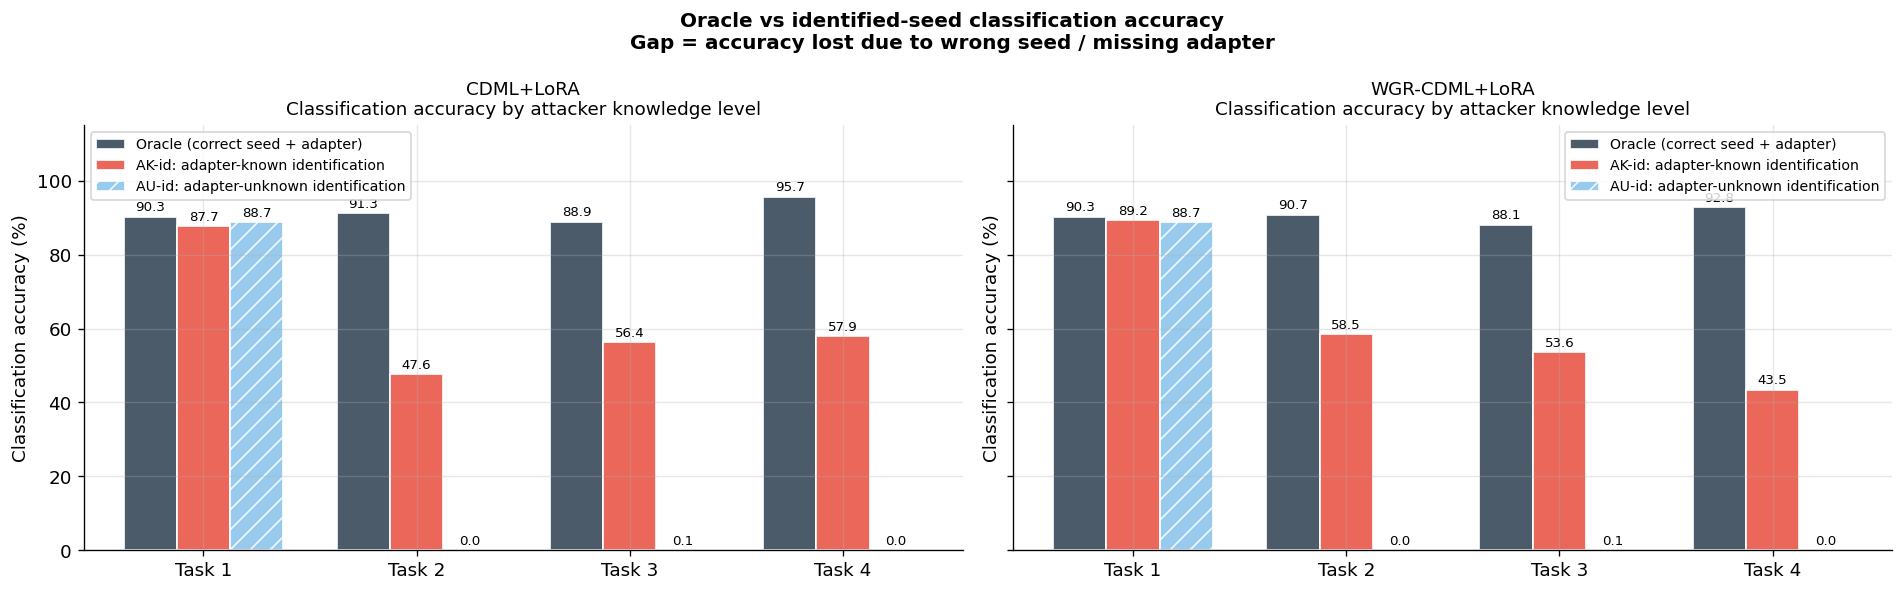

Saved: fig_3c_oracle_vs_identified.png


In [21]:
bar_colors  = ['#2C3E50', '#E74C3C', '#85C1E9']
bar_labels_ = ['Oracle (correct seed + adapter)',
               'AK-id: adapter-known identification',
               'AU-id: adapter-unknown identification']

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, (model_label, oracle_a, ak_a, au_a) in zip(axes, [
    ('CDML+LoRA',     oracle_cl, ak_cl, au_cl),
    ('WGR-CDML+LoRA', oracle_wl, ak_wl, au_wl),
]):
    x          = np.arange(len(task_names))
    width      = 0.25
    accs_list  = [[v * 100 for v in oracle_a],
                  [v * 100 for v in ak_a],
                  [v * 100 for v in au_a]]

    for i, (vals, color, lbl) in enumerate(zip(accs_list, bar_colors, bar_labels_)):
        offset = (i - 1) * width
        bars   = ax.bar(x + offset, vals, width, color=color, alpha=0.85,
                        label=lbl, edgecolor='white', linewidth=1.2,
                        hatch='//' if i == 2 else '')
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.7,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x); ax.set_xticklabels(task_names)
    ax.set_ylabel('Classification accuracy (%)')
    ax.set_ylim(0, 115)
    ax.set_title(f'{model_label}\nClassification accuracy by attacker knowledge level',
                 fontsize=11)
    ax.legend(fontsize=8.5)

plt.suptitle('Oracle vs identified-seed classification accuracy\n'
             'Gap = accuracy lost due to wrong seed / missing adapter',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../Plots/fig_3c_oracle_vs_identified.png', bbox_inches='tight')
plt.show()
print('Saved: fig_3c_oracle_vs_identified.png')


## 10. Final summary

In [22]:
sep = '=' * 76
print(sep)
print('PHASE 3c  --  FINAL SUMMARY')
print(sep)

print()
print('CDML SEED IDENTIFICATION ACCURACY  (random baseline = 25.0%)')
print('-' * 76)
print(f'  {"Scenario":<38} | ' +
      ' | '.join([f'{t:>8}' for t in task_names]) + ' |   Avg')
for scenario, res in ALL_RESULTS.items():
    accs = [res[t]['accuracy'] * 100 for t in task_names]
    mean = np.mean(accs)
    print(f'  {scenario:<38} | ' +
          ' | '.join([f'{a:>7.1f}%' for a in accs]) + f' | {mean:>5.1f}%')

print()
print('CLASSIFICATION ACCURACY AFTER SEED IDENTIFICATION')
print('-' * 76)
cls_rows = [
    ('CDML+LoRA     | Oracle',          oracle_cl),
    ('CDML+LoRA     | AK identification', ak_cl),
    ('CDML+LoRA     | AU identification', au_cl),
    ('WGR-CDML+LoRA | Oracle',          oracle_wl),
    ('WGR-CDML+LoRA | AK identification', ak_wl),
    ('WGR-CDML+LoRA | AU identification', au_wl),
]
print(f'  {"Condition":<40} | ' +
      ' | '.join([f'{t:>8}' for t in task_names]) + ' |   Avg')
for label, accs_ in cls_rows:
    vals = [v * 100 for v in accs_]
    mean = np.mean(vals)
    print(f'  {label:<40} | ' +
          ' | '.join([f'{v:>7.1f}%' for v in vals]) + f' | {mean:>5.1f}%')

print()
print('KEY OBSERVATIONS')
print('-' * 76)
for model_label, res_ak, res_au, oracle_a, ak_a, au_a in [
    ('CDML+LoRA',     results_cdml_ak, results_cdml_au, oracle_cl, ak_cl, au_cl),
    ('WGR-CDML+LoRA', results_wgr_ak,  results_wgr_au,  oracle_wl, ak_wl, au_wl),
]:
    id_ak  = np.mean([res_ak[t]['accuracy'] for t in task_names]) * 100
    id_au  = np.mean([res_au[t]['accuracy'] for t in task_names]) * 100
    cls_or = np.mean(oracle_a) * 100
    cls_ak = np.mean(ak_a)     * 100
    cls_au = np.mean(au_a)     * 100
    print(f'  {model_label}:')
    print(f'    Seed-ID accuracy  — adapter-known:   {id_ak:.1f}%  '
          f'(vs {baseline*100:.1f}% random)')
    print(f'    Seed-ID accuracy  — adapter-unknown: {id_au:.1f}%  '
          f'(vs {baseline*100:.1f}% random)')
    print(f'    Classification    — oracle:           {cls_or:.1f}%')
    print(f'    Classification    — AK identification:{cls_ak:.1f}%  '
          f'({cls_ak-cls_or:+.1f} pp vs oracle)')
    print(f'    Classification    — AU identification:{cls_au:.1f}%  '
          f'({cls_au-cls_or:+.1f} pp vs oracle)')
    print()


PHASE 3c  --  FINAL SUMMARY

CDML SEED IDENTIFICATION ACCURACY  (random baseline = 25.0%)
----------------------------------------------------------------------------
  Scenario                               |   Task 1 |   Task 2 |   Task 3 |   Task 4 |   Avg
  CDML+LoRA     | Adapter-known          |    95.7% |    48.4% |    57.2% |    58.5% |  64.9%
  CDML+LoRA     | Adapter-unknown        |    97.8% |    24.2% |    24.2% |    15.1% |  40.4%
  WGR-CDML+LoRA | Adapter-known          |    97.1% |    55.9% |    52.7% |    43.9% |  62.4%
  WGR-CDML+LoRA | Adapter-unknown        |    97.8% |    24.2% |    24.2% |    15.1% |  40.4%

CLASSIFICATION ACCURACY AFTER SEED IDENTIFICATION
----------------------------------------------------------------------------
  Condition                                |   Task 1 |   Task 2 |   Task 3 |   Task 4 |   Avg
  CDML+LoRA     | Oracle                   |    90.3% |    91.3% |    88.9% |    95.7% |  91.5%
  CDML+LoRA     | AK identification        | 